# 08 - Salinas Independent-Band Transformer

Goal: train the independent-band transformer baseline on Salinas. This is the expensive baseline that directly represents the tokenization bottleneck.

In [1]:
from pathlib import Path
import sys
import time

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from dfm.data.salinas import (
    SALINAS_CLASS_NAMES,
    SalinasPatchDataset,
    labeled_pixel_indices,
    load_salinas,
    stratified_train_test_split,
)
from dfm.experiments.token_scaling import attention_cost_proxy, independent_band_tokens
from dfm.models.transformer_baseline import IndependentBandTransformerClassifier
from dfm.training.metrics import accuracy_score, macro_f1_score
from dfm.training.profiling import count_parameters

c:\Users\Dines\Documents\Codex\2026-05-15\files-mentioned-by-the-user-dataset0\dense-forest-monitoring\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Experiment Settings

`TRANSFORMER_PATCH_SIZE=15` is the fast CPU-safe baseline. Change it to `5` for a heavier independent-band transformer with more spatial tokens.

In [10]:
SEED = 42
INPUT_PATCH_SIZE = 15
TRANSFORMER_PATCH_SIZE = 5  # Try 5 later for a heavier tokenization baseline.
EMBED_DIM = 64
DEPTH = 2
NUM_HEADS = 4
EPOCHS = 5
BATCH_SIZE = 64 if TRANSFORMER_PATCH_SIZE == 15 else 16

np.random.seed(SEED)
torch.manual_seed(SEED)

tokens = independent_band_tokens(
    height=INPUT_PATCH_SIZE,
    width=INPUT_PATCH_SIZE,
    bands=204,
    patch_size=TRANSFORMER_PATCH_SIZE,
)
print("Transformer patch size:", TRANSFORMER_PATCH_SIZE)
print("Independent-band tokens per sample:", tokens)
print("Attention cost proxy:", attention_cost_proxy(tokens))
print("Batch size:", BATCH_SIZE)

Transformer patch size: 5
Independent-band tokens per sample: 1836
Attention cost proxy: 3370896
Batch size: 16


In [11]:
data_dir = PROJECT_ROOT / "data" / "raw" / "salinas"
scene = load_salinas(data_dir, download=True)
rows, cols, labels = labeled_pixel_indices(scene.labels)
train_indices, test_indices = stratified_train_test_split(labels, train_fraction=0.1, seed=SEED)

train_dataset = SalinasPatchDataset(scene, indices=train_indices, patch_size=INPUT_PATCH_SIZE)
test_dataset = SalinasPatchDataset(scene, indices=test_indices, patch_size=INPUT_PATCH_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=max(BATCH_SIZE, 128), shuffle=False, num_workers=0)

print("Cube shape (H, W, C):", scene.cube.shape)
print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))
sample_x, sample_y = train_dataset[0]
print("Sample patch:", sample_x.shape, "label:", sample_y)

Cube shape (H, W, C): (512, 217, 204)
Train samples: 5415
Test samples: 48714
Sample patch: (204, 15, 15) label: 8


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = IndependentBandTransformerClassifier(
    num_classes=len(SALINAS_CLASS_NAMES),
    patch_size=TRANSFORMER_PATCH_SIZE,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    num_heads=NUM_HEADS,
    dropout=0.1,
    max_bands=256,
    max_patches=4096,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

print("Device:", device)
print("Trainable parameters:", count_parameters(model))

Device: cpu
Trainable parameters: 381392


In [13]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    total = 0
    start = time.perf_counter()
    for x, y in tqdm(loader, leave=False):
        x = x.to(device=device, dtype=torch.float32)
        y = y.to(device=device, dtype=torch.long)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item()) * x.shape[0]
        total += x.shape[0]
    return total_loss / total, time.perf_counter() - start


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_true = []
    all_pred = []
    start = time.perf_counter()
    for x, y in tqdm(loader, leave=False):
        x = x.to(device=device, dtype=torch.float32)
        logits = model(x)
        pred = logits.argmax(dim=1).cpu().numpy()
        all_pred.append(pred)
        all_true.append(y.numpy())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": macro_f1_score(y_true, y_pred, num_classes=len(SALINAS_CLASS_NAMES)),
        "eval_seconds": time.perf_counter() - start,
    }

In [14]:
history = []
best_macro_f1 = -1.0
best_state = None
best_epoch = None

for epoch in range(1, EPOCHS + 1):
    train_loss, train_seconds = train_one_epoch(model, train_loader)
    metrics = evaluate(model, test_loader)
    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_seconds": train_seconds,
        **metrics,
    }
    history.append(row)

    if metrics["macro_f1"] > best_macro_f1:
        best_macro_f1 = metrics["macro_f1"]
        best_epoch = epoch
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

    print(row)

history_df = pd.DataFrame(history)
print(f"Best epoch by macro-F1: {best_epoch} ({best_macro_f1:.4f})")
history_df

  0%|          | 0/339 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.5343576302929047, 'train_seconds': 5648.778415299952, 'accuracy': 0.6561768690725459, 'macro_f1': 0.5223239045919346, 'eval_seconds': 6914.004244400072}


{'epoch': 2, 'train_loss': 0.758602709012899, 'train_seconds': 15494.750707700034, 'accuracy': 0.8120458184505481, 'macro_f1': 0.7879206179257786, 'eval_seconds': 5915.056562999962}


{'epoch': 3, 'train_loss': 0.4726277554244326, 'train_seconds': 5200.184005399933, 'accuracy': 0.863653159256066, 'macro_f1': 0.8405417531592447, 'eval_seconds': 5675.268887800048}


{'epoch': 4, 'train_loss': 0.32313228708555164, 'train_seconds': 4254.826629900024, 'accuracy': 0.9171696021677547, 'macro_f1': 0.9224940290938047, 'eval_seconds': 5027.628997000051}


{'epoch': 5, 'train_loss': 0.2360369762018777, 'train_seconds': 4158.816461700015, 'accuracy': 0.9289526624789588, 'macro_f1': 0.9436337699191482, 'eval_seconds': 5342.198881999939}
Best epoch by macro-F1: 5 (0.9436)


,epoch,train_loss,train_seconds,accuracy,macro_f1,eval_seconds
0,1,1.534358,5648.778415,0.656177,0.522324,6914.004244
1,2,0.758603,15494.750708,0.812046,0.787921,5915.056563
2,3,0.472628,5200.184005,0.863653,0.840542,5675.268888
3,4,0.323132,4254.826630,0.917170,0.922494,5027.628997
4,5,0.236037,4158.816462,0.928953,0.943634,5342.198882


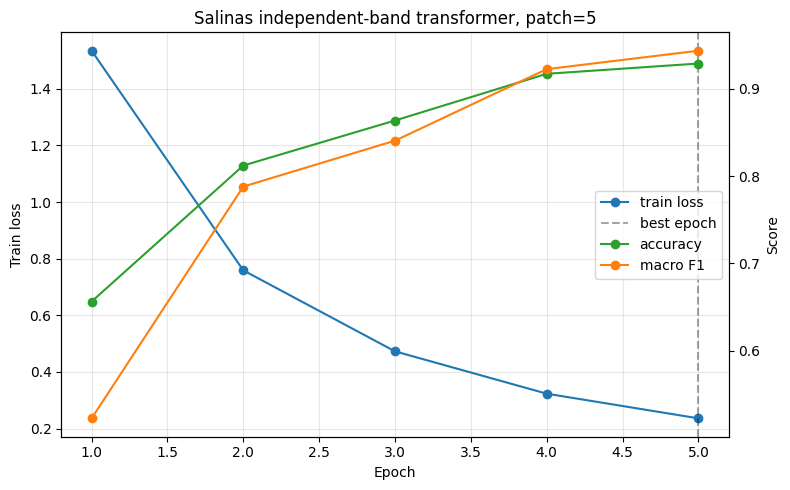

In [15]:
outputs_dir = PROJECT_ROOT / "outputs" / "salinas"
outputs_dir.mkdir(parents=True, exist_ok=True)

run_name = f"transformer_patch{TRANSFORMER_PATCH_SIZE}"
history_path = outputs_dir / f"{run_name}_history.csv"
checkpoint_path = outputs_dir / f"{run_name}_best.pt"
figure_path = outputs_dir / f"{run_name}_history.png"

history_df.to_csv(history_path, index=False)
if best_state is not None:
    torch.save(
        {
            "model_state_dict": best_state,
            "best_epoch": best_epoch,
            "best_macro_f1": best_macro_f1,
            "class_names": SALINAS_CLASS_NAMES,
            "input_patch_size": INPUT_PATCH_SIZE,
            "transformer_patch_size": TRANSFORMER_PATCH_SIZE,
            "bands": scene.bands,
            "tokens": tokens,
            "attention_cost_proxy": attention_cost_proxy(tokens),
        },
        checkpoint_path,
    )

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train loss")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(history_df["epoch"], history_df["accuracy"], marker="o", color="tab:green", label="accuracy")
ax2.plot(history_df["epoch"], history_df["macro_f1"], marker="o", color="tab:orange", label="macro F1")
if best_epoch is not None:
    ax1.axvline(best_epoch, color="black", linestyle="--", alpha=0.35, label="best epoch")
ax2.set_ylabel("Score")

lines, labels_ = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels_ + labels2, loc="center right")
plt.title(f"Salinas independent-band transformer, patch={TRANSFORMER_PATCH_SIZE}")
plt.tight_layout()
plt.savefig(figure_path, dpi=200);

## Compare With Existing Results

In [16]:
comparison_rows = []

for model_name, csv_name in [
    ("CNN baseline", "cnn_baseline_history.csv"),
    ("Hybrid spatial-spectral", "hybrid_baseline_history.csv"),
    (f"Independent-band transformer p={TRANSFORMER_PATCH_SIZE}", history_path.name),
]:
    path = outputs_dir / csv_name
    if not path.exists():
        continue
    history = pd.read_csv(path)
    best = history.loc[history["macro_f1"].idxmax()]
    comparison_rows.append({
        "model": model_name,
        "best_epoch": int(best["epoch"]),
        "accuracy": float(best["accuracy"]),
        "macro_f1": float(best["macro_f1"]),
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(outputs_dir / f"cnn_hybrid_transformer_patch{TRANSFORMER_PATCH_SIZE}_comparison.csv", index=False)
comparison_df

,model,best_epoch,accuracy,macro_f1
0,CNN baseline,4,0.948249,0.974376
1,Hybrid spatial-spectral,3,0.973334,0.979062
2,Independent-band transformer p=5,5,0.928953,0.943634
